### 20.1-6

**Problem statement**

Most graph algorithms that take an adjacency-matrix representation as
input require Ω(V<sup>2</sup>) time, but there are some exceptions. Show how to determine whether a directed graph G contains a universal sink—a
vertex with in-degree |V| – 1 and out-degree 0—in O(V) time, given an adjacency matrix for G.

Said in plain english we need to figure out if there is a vertex in some graph where all the other vertices have an edge to it and itself points to noone.

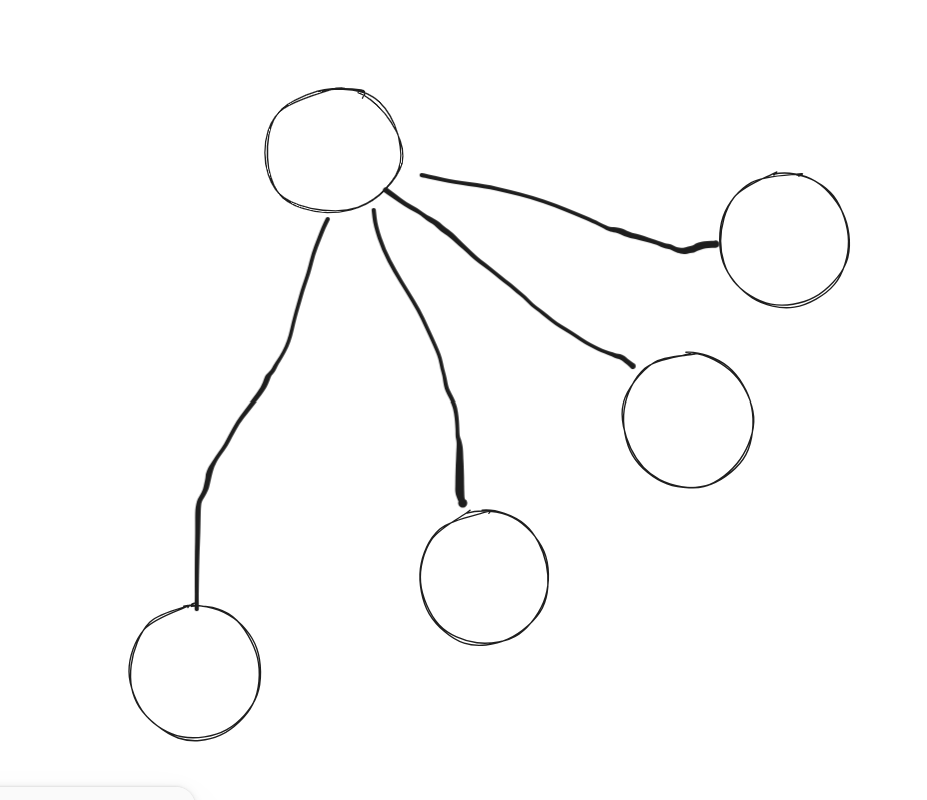

That is essentially a situation where we have a graph like this above and below is an example matrix

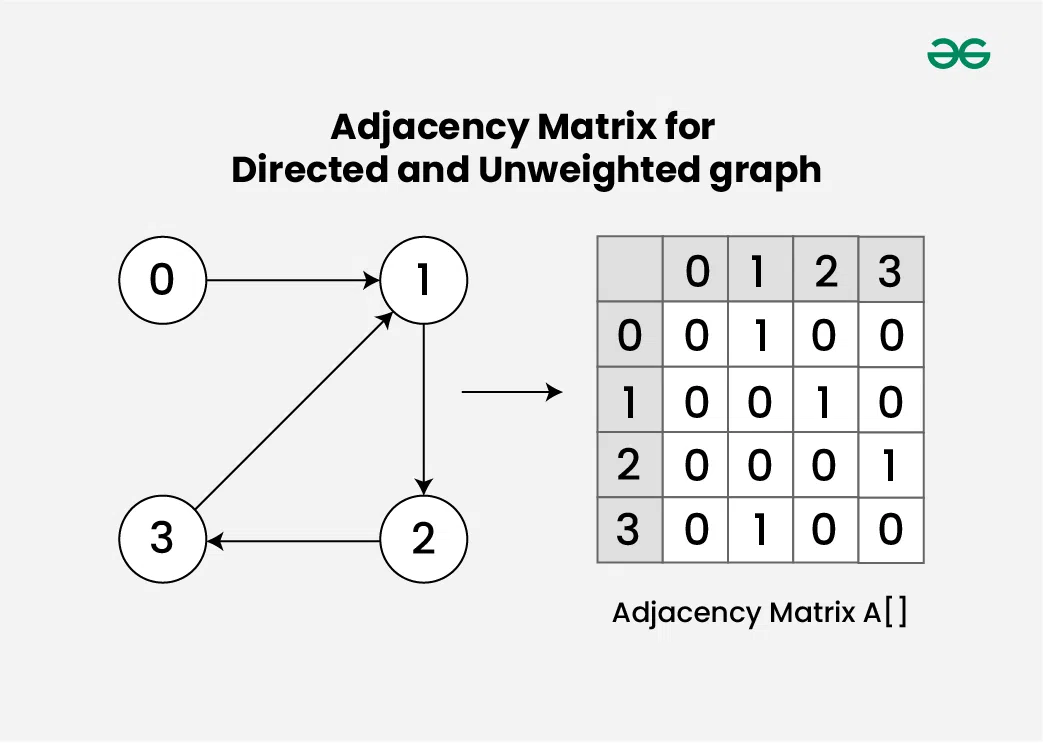

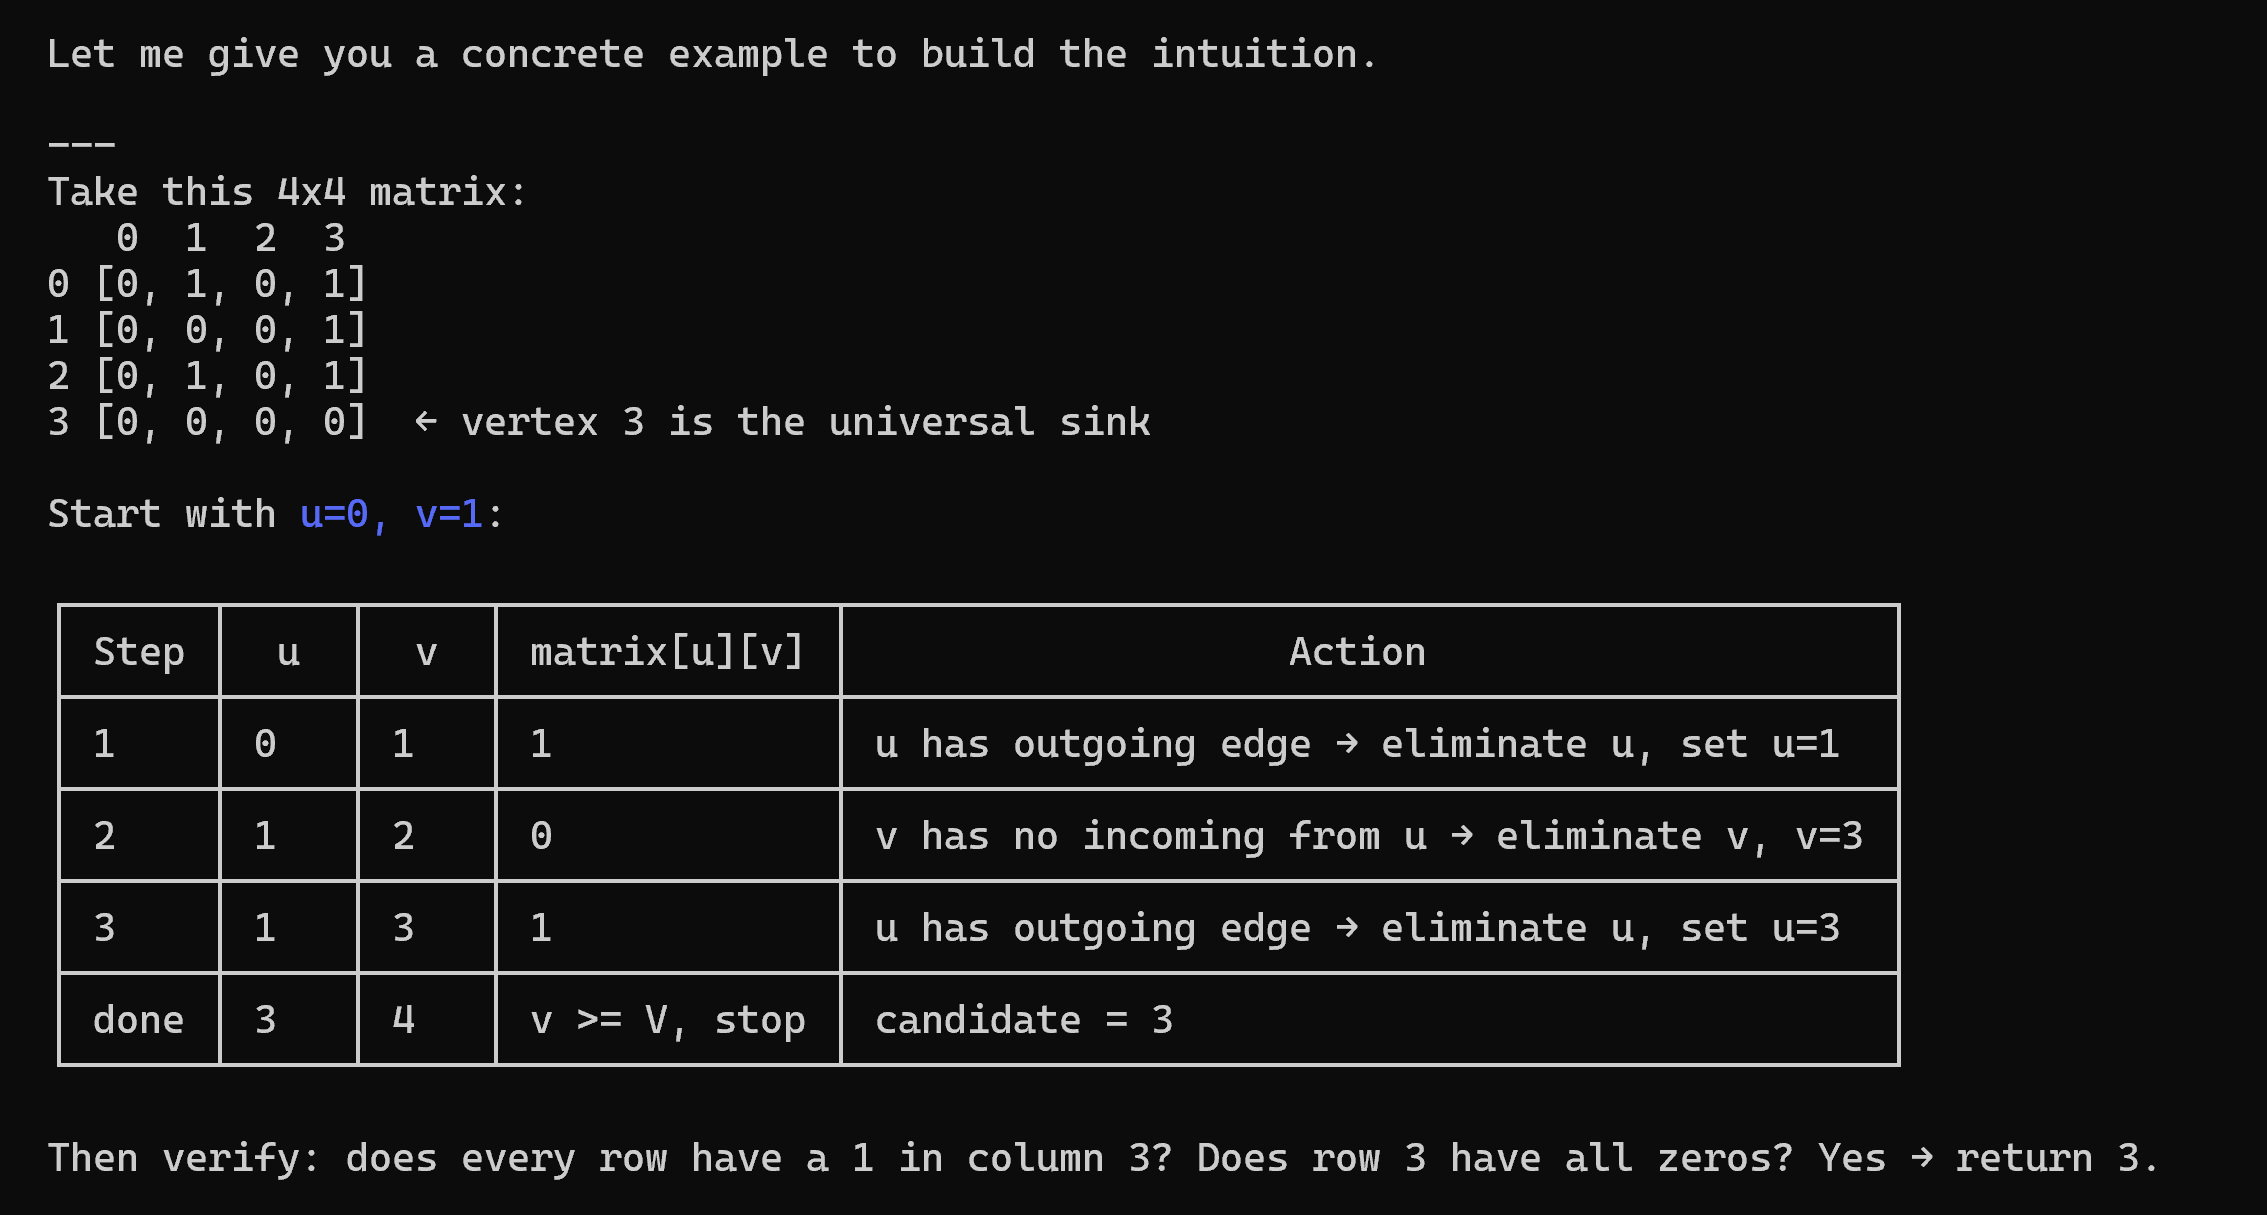

  Insight 1: A universal sink is uniquely identifiable from the matrix

  A universal sink has an entire row of zeros (no outgoing edges) and an entire column of ones except the diagonal (everyone points to it). This
   means it has a very specific signature in the matrix — and there can be at most one such vertex in any graph.

  ---
  Insight 2: Every cell eliminates exactly one candidate

  When you look at matrix[u][v]:
  - If it's 1 → u has an outgoing edge. A universal sink has zero outgoing edges. So u is eliminated.
  - If it's 0 → v has no incoming edge from u. A universal sink must have incoming edges from everyone. So v is eliminated.

  No matter what the cell contains, you always eliminate one candidate. You never waste a step.

  ---
  Insight 3: The two pointers never need to go back

  Because you eliminate one candidate per step and never reconsider eliminated vertices, both u and v only move forward. v increases
  monotonically until it hits V. This is what gives you O(V) — you scan at most V cells in the elimination phase.

  ---
  The broader lesson

  This algorithm is a good example of a pattern that appears throughout algorithm design: instead of checking everything (O(V²)), find a local
  rule that lets you eliminate candidates one by one. The same idea appears in binary search, the two-pointer technique for sorted arrays, and
  several other O(n) algorithms that at first glance seem to require O(n²).

In [50]:
def universal_sink(matrix):
      V = len(matrix)
      u, v = 0, 1
      # elimination phase — narrow down to one candidate
      while v < V:
          if matrix[u][v] == 1:
              u = v      # u has outgoing edge, eliminate u
          else:
              v += 1     # v has no incoming edge from u, eliminate v

      candidate = u

      # verification phase — check candidate has in-degree V-1 and out-degree 0
      for i in range(V):
          if i == candidate:
              continue
          # what do you check here?
          if matrix[i][candidate] != 1 or matrix[candidate][i] != 0:
              return None

      return candidate

 The two phases do different jobs:
  - Elimination — rules out all vertices that definitely cannot be a universal sink, in O(V)
  - Verification — confirms the remaining candidate actually is one, in O(V)

  The clever part is that elimination guarantees at most one candidate survives — so you only ever need to verify once.

In [52]:
matrix = [
    [0, 0, 1],
    [1, 0, 0],
    [1, 0, 0],
]